# BSW Sensor Optimization: Pareto Front Visualization 📊

This notebook loads the optimization results (`.pkl` files) generated by the multi-objective algorithms (NSGA-II). It is designed to visualize the Pareto Fronts, comparing the Sensitivity (S_I) against the Robustness Figure of Merit (FOM_R) for the analyzed multilayer configurations.

## 1. Import Libraries & Setup
Setting up the necessary Python libraries for data handling and plotting.

In [10]:
import pickle
from pathlib import Path
import matplotlib.pyplot as plt


plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial'], 
    'mathtext.fontset': 'cm',     
    'font.size': 9*3,
    'axes.labelsize': 10*3,
    'xtick.labelsize': 8*3,
    'ytick.labelsize': 8*3,
    'legend.fontsize': 8*3,
    
    'figure.figsize': (3.4*2.5, 2.4*2.5), 
    
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': False,            
    'ytick.right': False,          
    
    'axes.facecolor': '#FFFFFF', 
    'figure.facecolor': 'white',
    
    'axes.grid': True,
    'grid.color': "#BABABA",
    'grid.linestyle': '--',
    'grid.linewidth': 0.8,
    'axes.axisbelow': True, 
    
    'axes.spines.top': True,
    'axes.spines.right': True,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
})

## 2. Data Loading
Loading the final Pareto fronts for both Periodic and Non-Periodic configurations from the saved Pickle files.

In [16]:
dataset_path = Path(r"C:\Users\ricky\Desktop\Robust_NP_BSW_sensors\data\Paretofront")

# Loading Non Periodic Front
with open(dataset_path / "Final_front.pkl", 'rb') as f:
    data_np = pickle.load(f)

# Loading Periodic Front
with open(dataset_path / "Periodic_Final_front.pkl", 'rb') as f:
    data_p = pickle.load(f)

## 3. Pareto Front Plot
Generating the scatter plot comparing the Non-Periodic and Periodic configurations. 

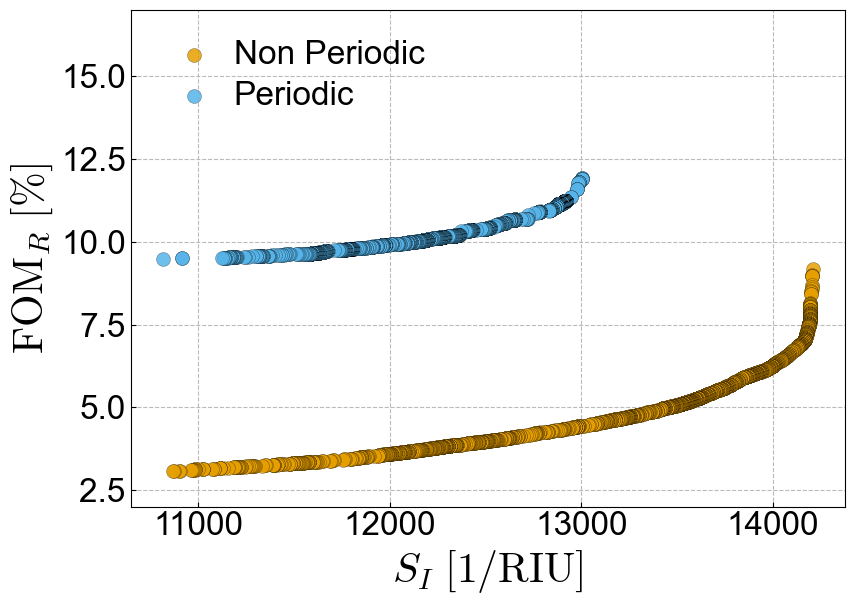

In [12]:
fig, ax = plt.subplots()

# Plot Fronte Non Periodico (Cerchi, Arancione Okabe-Ito)
ax.scatter(data_np["S_I"], data_np["FOM_R"], 
           s=100, 
           alpha=0.85, 
           label="Non Periodic", 
           color='#E69F00',       
           edgecolor='black',     
           linewidth=0.2)         

# Plot Fronte Periodico (Cerchi, Azzurro Okabe-Ito)
ax.scatter(data_p["S_I"], data_p["FOM_R"], 
           s=100, 
           alpha=0.85, 
           label="Periodic", 
           color='#56B4E9',       
           edgecolor='black',
           linewidth=0.2)

# ==========================================
# ETICHETTE E STILE
# ==========================================
ax.set_xlabel(r'$S_I$ $[1/\mathrm{RIU}]$', labelpad=4)
ax.set_ylabel(r'$\mathrm{FOM}_R$ $[\%]$', labelpad=4)
ax.set_ylim(2, 17)

ax.legend(loc='upper left', 
          frameon=False, 
          handletextpad=0.2, 
          labelspacing=0.3,
          shadow=True)

plt.tight_layout(pad=0.2)

## 4. Perturbation Ensamble Validation
This section performs the perturbation ensemble validation of the final Pareto front. The original Pareto front structures are represented as circles, and their corresponding re-evaluated $\mathrm{FOM}_R$ values are plotted as triangles. 

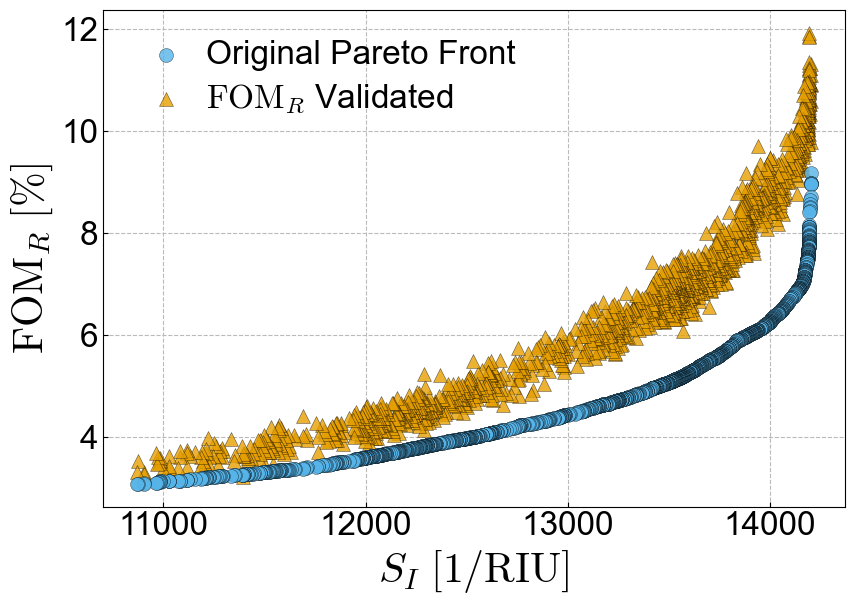

In [20]:
fig, ax = plt.subplots()

S_I = data_np["S_I"]
FOM_R_original = data_np["FOM_R"]
FOM_R_validated = data_np["FOM_R_recalculation_Perturbation_ensemble_validation"]

ax.scatter(S_I, FOM_R_original, 
           s=100, 
           alpha=0.8, 
           label="Original Pareto Front", 
           color='#56B4E9',       # Azzurro
           edgecolor='black',     
           linewidth=0.3,
           marker='o',
           zorder=2)         


ax.scatter(S_I, FOM_R_validated, 
           s=100, 
           alpha=0.8, 
           label=r"$\mathrm{FOM}_R$ Validated", 
           color='#E69F00',       # Arancione
           edgecolor='black',
           linewidth=0.3,
           marker='^',            
           zorder=1)


ax.set_xlabel(r'$S_I$ $[1/\mathrm{RIU}]$', labelpad=4)
ax.set_ylabel(r'$\mathrm{FOM}_R$ $[\%]$', labelpad=4)

ax.legend(loc='upper left', 
          frameon=False, 
          handletextpad=0.2, 
          labelspacing=0.3,
          shadow=True)

plt.tight_layout(pad=0.2)
